In [2]:
import numpy as np

def generate_mixed_positions(
    N,
    L,
    frac_agg,
    n_centers,
    base_sigma,
    rng,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20
):
    """
    Genera posiciones en un dominio cuadrado L x L.

    sigma_mode:
        "same"   -> todos los centros tienen sigma = base_sigma
        "random" -> cada centro tiene una sigma aleatoria entre sigma_min y sigma_max
    """

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    # ============================================================
    # Centros de agregación
    # ============================================================

    centers = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(n_centers, 2)
    )

    # ============================================================
    # Sigma de cada centro
    # ============================================================

    if sigma_mode == "same":
        sigmas = np.full(n_centers, base_sigma)

    elif sigma_mode == "random":
        sigmas = rng.uniform(
            low=sigma_min,
            high=sigma_max,
            size=n_centers
        )

    else:
        raise ValueError("sigma_mode debe ser 'same' o 'random'")

    # ============================================================
    # Neuronas agregadas
    # ============================================================

    positions_agg = []

    for i in range(N_agg):
        # Elegimos un centro al azar
        c_idx = rng.integers(0, n_centers)

        center = centers[c_idx]
        sigma = sigmas[c_idx]

        # Generamos una neurona alrededor de ese centro
        pos = rng.normal(
            loc=center,
            scale=sigma,
            size=2
        )

        # Si cae fuera del dominio, la reintentamos
        while (
            pos[0] < -L/2 or pos[0] > L/2 or
            pos[1] < -L/2 or pos[1] > L/2
        ):
            pos = rng.normal(
                loc=center,
                scale=sigma,
                size=2
            )

        positions_agg.append(pos)

    positions_agg = np.array(positions_agg)

    # ============================================================
    # Neuronas random
    # ============================================================

    positions_rand = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(N_rand, 2)
    )

    # ============================================================
    # Juntar posiciones
    # ============================================================

    positions = np.vstack([positions_agg, positions_rand])

    labels = np.array(["agg"] * N_agg + ["rand"] * N_rand)

    return positions, centers, labels, sigmas



def create_distance_network(
    positions,
    r_conn,
    alpha=0.2,
    directed=False,
    rng=None
):
    """
    Crea una matriz de adyacencia A.

    Si la distancia entre dos neuronas es menor que r_conn,
    se conectan con probabilidad alpha.

    directed=False crea una red no dirigida.
    directed=True crea una red dirigida.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=int)

    if directed:

        for i in range(N):
            for j in range(N):

                if i == j:
                    continue

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1

    else:

        for i in range(N):
            for j in range(i + 1, N):

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1
                        A[j, i] = 1

    return A

def Gini(X,Y, L, n_grid):

    H, x_edges, y_edges = np.histogram2d(
        X, Y,
        bins=n_grid,
        range=[[-L/2, L/2], [-L/2, L/2]]
    )

    H_flat = H.flatten()
    H_flat = np.sort(H_flat)[::-1]

    G = np.zeros(len(H_flat))
    sum_gini = 0.0

    for i, h in enumerate(H_flat):
        sum_gini += h
        G[i] = sum_gini / H.sum()

    bins = np.arange(1, len(H_flat) + 1)
    bins = bins / len(H_flat)

    area_between = np.trapezoid(G - bins, bins)
    Gini = 2 * area_between

    H_plot = H.T  # Transponer para que el eje x corresponda a X y el eje y a Y

    return Gini, H_plot, x_edges, y_edges

Número de neuronas inicial: 1000
Número de enlaces inicial: 13649
Grado medio inicial: 27.298
Densidad inicial: 0.027325325325325327
La red inicial no es conexa
Tamaño de la componente gigante: 119
Fracción en componente gigante: 0.119

Después de quedarnos con la componente gigante:
Número de neuronas: 119
Número de enlaces: 1983
Grado medio: 33.32773109243698
Densidad: 0.2824383990884489
¿Es conexa ahora?: True
Número de comunidades detectadas en la red completa: 159
Tamaños de comunidades red completa: [119, 76, 75, 74, 74, 72, 69, 69, 69, 67, 56, 4, 4, 4, 4, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

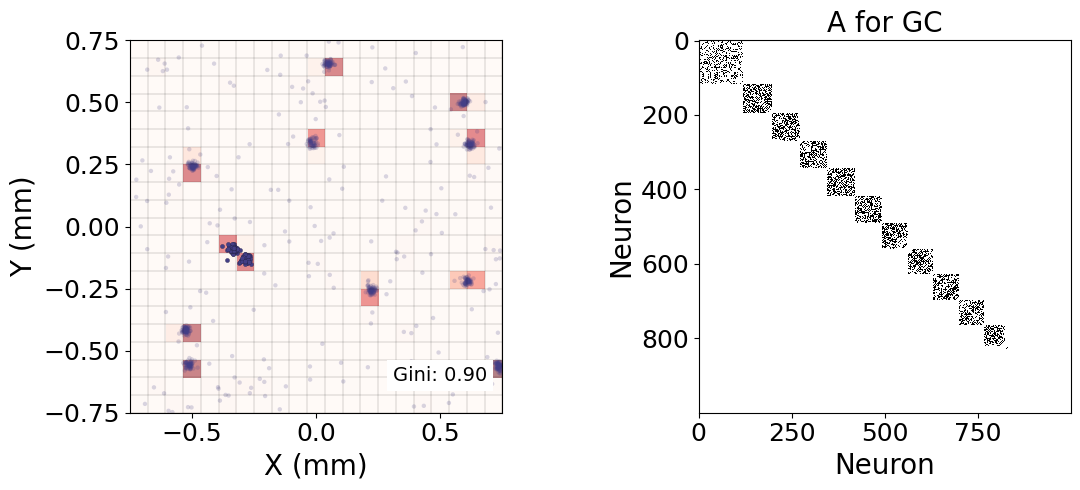

In [5]:
# Poner neuronas en un plano de LxL
## Poner un 70% agragadas y el otro 30% random
## La agregación la hacemos poniendo unos centros de menra aleatoria en la red con una cierta anchura y 
## colocando las neuronas en esos centros, el resto random en el espacio.
# Generar conexiones de acuerdo a la distancia entre neuronas con una cierta probabilidad de conexión.

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pypalettes import load_cmap

viridis = load_cmap("viridis")


# ============================================================
# Parámetros principales
# ============================================================

L = 1.5              # Tamaño del dominio L x L, en mm
N = 1000          # Número total de neuronas
Neuron_per_center = 80
frac_agg = 0.8 # Fracción de neuronas agregadas
n_centers = N // Neuron_per_center  # Número de centros de agregación
base_sigma = 0.01    # Anchura de los agregados, en mm

r_conn = 0.05   # Radio de conexión, en mm
alpha = 0.5       # Probabilidad de conexión si están dentro del radio

seed = np.random.SeedSequence().entropy
rng = np.random.default_rng(seed)


# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng,
    sigma_mode="same",   # "same" o "random"
    sigma_min=0.05,
    sigma_max=0.20
)

# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)

# ============================================================
# Convertir a grafo de NetworkX
# ============================================================
# ============================================================
# Convertir a grafo de NetworkX y quedarse con la componente gigante
# ============================================================

# ============================================================
# Convertir a grafo de NetworkX y detectar componente gigante
# ============================================================

A_full = A.copy()
positions_full = positions.copy()
labels_full = labels.copy()
N_full = N

G_full = nx.from_numpy_array(A_full)

print("Número de neuronas inicial:", N_full)
print("Número de enlaces inicial:", G_full.number_of_edges())
print("Grado medio inicial:", np.mean([d for _, d in G_full.degree()]))
print("Densidad inicial:", nx.density(G_full))

if nx.is_connected(G_full):
    print("La red inicial es conexa")
    GC_nodes = np.arange(N_full)

else:
    GC = max(nx.connected_components(G_full), key=len)
    GC_nodes = np.array(sorted(list(GC)))

    print("La red inicial no es conexa")
    print("Tamaño de la componente gigante:", len(GC_nodes))
    print("Fracción en componente gigante:", len(GC_nodes) / N_full)

# Máscara booleana para saber qué nodos pertenecen a la CG
is_GC = np.zeros(N_full, dtype=bool)
is_GC[GC_nodes] = True

# ============================================================
# Reducir A, positions, labels y N a la componente gigante
# para TODO lo que venga después: Louvain, dinámica, etc.
# ============================================================

A = A_full[np.ix_(GC_nodes, GC_nodes)] # This is the adjacency matrix of the giant component
np.save("A_GC.npy", A)
positions = positions_full[GC_nodes]
np.save("positions_GC.npy", positions)
labels = labels_full[GC_nodes]

N_original = N_full
N = A.shape[0]

G = nx.from_numpy_array(A)

print("\nDespués de quedarnos con la componente gigante:")
print("Número de neuronas:", N)
print("Número de enlaces:", G.number_of_edges())
print("Grado medio:", np.mean([d for _, d in G.degree()]))
print("Densidad:", nx.density(G))
print("¿Es conexa ahora?:", nx.is_connected(G))

# ============================================================
# Ordenar matriz de adyacencia por comunidades
# ============================================================

# Grafo completo, no solo la componente gigante
G_for_plot = nx.from_numpy_array(A_full)

# Detectar comunidades en toda la red
communities_full = nx.community.louvain_communities(G_for_plot, seed=seed)

# Ordenar comunidades por tamaño, de mayor a menor
communities_full = sorted(communities_full, key=len, reverse=True)

# Lista de nodos ordenados por comunidad
ordered_nodes_full = []
community_boundaries_full = []

count = 0
for comm in communities_full:
    comm_sorted = sorted(list(comm))
    ordered_nodes_full.extend(comm_sorted)

    count += len(comm_sorted)
    community_boundaries_full.append(count)

# Reordenar la matriz completa
A_full_ordered = A_full[np.ix_(ordered_nodes_full, ordered_nodes_full)]

print("Número de comunidades detectadas en la red completa:", len(communities_full))
print("Tamaños de comunidades red completa:", [len(c) for c in communities_full])


# ============================================================
# Plot conjunto: posiciones + matriz de adyacencia ordenada
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1, 1]}
)

# ============================================================
# Izquierda: distribución espacial
# ============================================================

# ============================================================
# Izquierda: distribución espacial completa
# ============================================================

ax = axes[0]

# Primero ploteamos los nodos que NO están en la CG
ax.scatter(
    positions_full[~is_GC, 0],
    positions_full[~is_GC, 1],
    s=10,
    alpha=0.2,
    color=viridis(0.1),
    label="Out GC",
    edgecolors='none'
)

n_grid = 21
Gini_coeff, H_plot, x_edges, y_edges = Gini(
    X=positions_full[:, 0],
    Y=positions_full[:, 1],
    L=L,
    n_grid=n_grid
)

xmin = -L/2
xmax = L/2
ymin = -L/2
ymax = L/2

x_grid = np.linspace(xmin, xmax, n_grid + 1)
y_grid = np.linspace(ymin, ymax, n_grid + 1)

for x in x_grid:
    ax.axvline(x, color='black', lw=0.3, alpha=0.4)

for y in y_grid:
    ax.axhline(y, color='black', lw=0.3, alpha=0.4)

ax.imshow(
    H_plot,
    extent=[xmin, xmax, ymin, ymax],
    origin='lower',
    cmap='Reds',
    alpha=0.5
)

ax.text(
    0.5, -0.6,
    f"Gini: {Gini_coeff:.2f}",
    fontsize=14,
    color='black',
    ha='center',
    va='center',
    bbox=dict(facecolor='white', alpha=1, edgecolor='none')
)

# SHow a grid using n_grid 

# Después ploteamos encima los nodos de la CG
ax.scatter(
    positions_full[is_GC, 0],
    positions_full[is_GC, 1],
    s=10,
    alpha=1,
    color=viridis(0.1),
    label="GC", 
    edgecolors='black', 
    linewidths=0.1
)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_aspect("equal")

ax.set_xlabel("X (mm)", fontsize=20)
ax.set_ylabel("Y (mm)", fontsize=20)
# Legend makong bigger the dots, alph = 0.8 a to make it more visible, and frameon to make it more clear
# legend = ax.legend(frameon=True, fontsize=18, loc="best", markerscale=3, framealpha = 1.0, edgecolor = "black")
ax.tick_params(labelsize=18)


# ============================================================
# Derecha: matriz de adyacencia ordenada por comunidades
# ============================================================

ax = axes[1]

im = ax.imshow(
    A_full_ordered,
    cmap="Greys",
    interpolation="nearest",
    origin="upper"
)

ax.set_title("A for GC", fontsize=20)
ax.set_xlabel("Neuron", fontsize = 20)
ax.set_ylabel("Neuron", fontsize = 20)
ax.tick_params(labelsize=18)
# ax.set_xticks([0, 1000, 2000])
# ax.set_xticklabels(["0", "1k", "2k"])
# ax.set_yticks([0, 1000, 2000])
# ax.set_yticklabels(["0", "1k", "2k"])

# Dibujar líneas separando comunidades
# for boundary in community_boundaries[:-1]:
#     ax.axhline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)
#     ax.axvline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

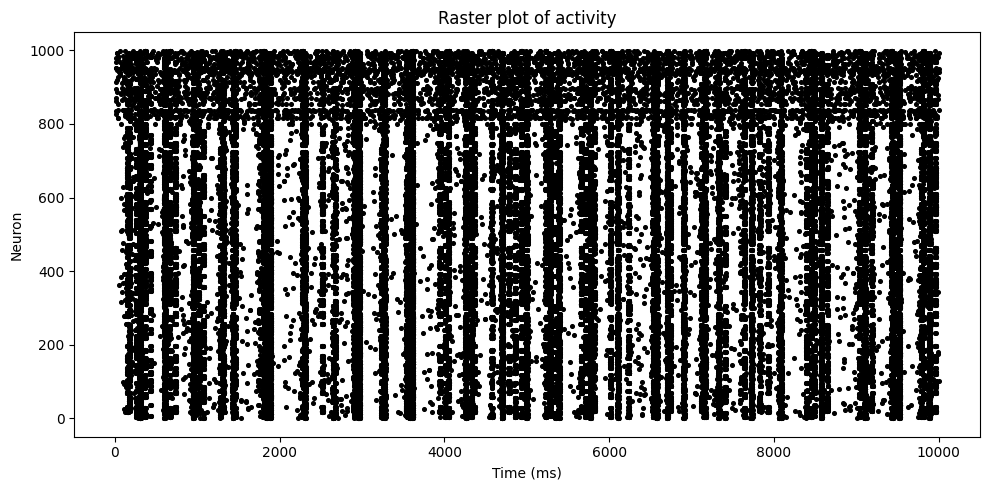

In [48]:
 
# Reproducibilidad opcional
np.random.seed(42)

## Simulations
Ne = int(0.8 * N)  # Número de neuronas excitatorias
Ni = N - Ne        # Número de neuronas inhibitorias

SIM_TIME = 10000
MAX_EXC_WEIGHT = 8
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(N, Ne),
    -MAX_INH_WEIGHT * np.random.rand(N, Ni)
])

S = A * W

# =========================
# Izhikevich parameters
# =========================

re = np.random.rand(Ne)
ri = np.random.rand(Ni)

a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])

# =========================
# MAIN SIMULATION
# =========================

NOISE_MAX = 3

v = -65 * np.ones(N)
u = b * v

firings = []

for t in range(1, SIM_TIME + 1):

    I = np.concatenate([
        NOISE_MAX * np.random.randn(Ne),
        2 * np.random.randn(Ni)
    ])

    fired = np.where(v >= 30)[0]

    if len(fired) > 0:
        firings.extend([(t, neuron) for neuron in fired])

        v[fired] = c[fired]
        u[fired] += d[fired]

        I += np.sum(S[:, fired], axis=1)

    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u += a * (b * v - u)

firings = np.array(firings)

# =========================
# Raster plot
# =========================

plt.figure(figsize=(10, 5))

plt.scatter(
    firings[:, 0],
    firings[:, 1],
    s=7,
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron")
plt.title("Raster plot of activity")
plt.tight_layout()
plt.show()

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3065: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3066: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Threshold para top 10% de |Pearson|: 0.0317
Número de enlaces funcionales binarios: 40907


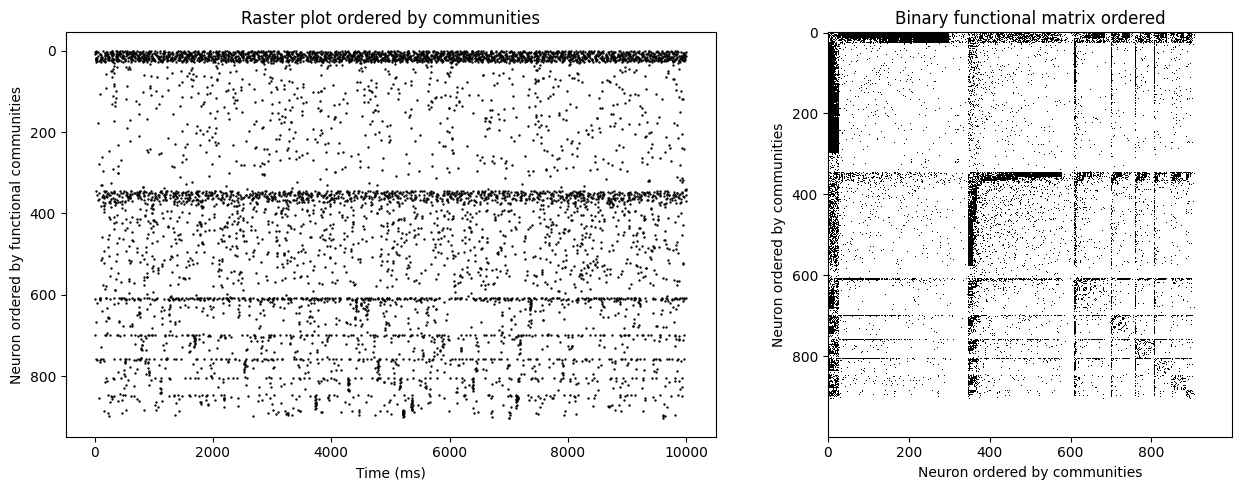

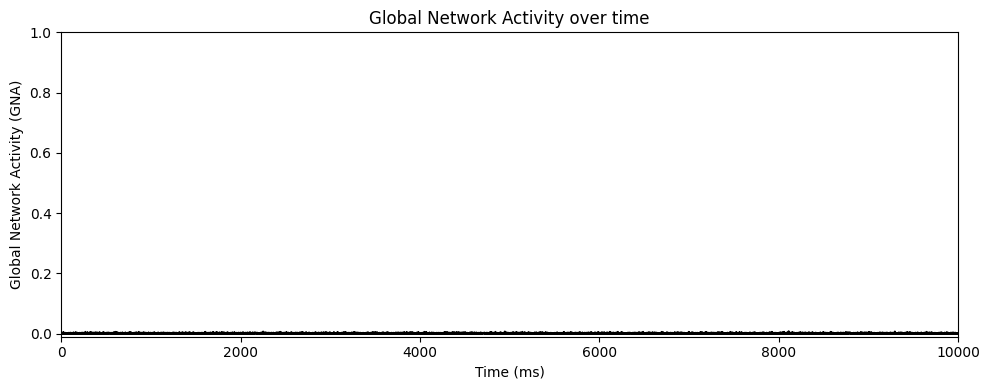

Mean peak height: nan


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.signal as signal
from scipy.signal import find_peaks

# ============================================================
# FUNCIONES
# ============================================================

def build_activity_matrix_from_raster(firings, N, SIM_TIME, bin_size=25):
    """
    Construye una matriz M de actividad neuronal.
    
    M[t_bin, neuron] = 1 si la neurona dispara al menos una vez
    en esa ventana temporal.
    """
    
    n_bins = int(np.ceil(SIM_TIME / bin_size))
    M = np.zeros((n_bins, N), dtype=float)
    
    if firings.size == 0:
        return M
    
    times = firings[:, 0].astype(int)
    neurons = firings[:, 1].astype(int)
    
    bin_indices = (times - 1) // bin_size
    
    valid = (bin_indices >= 0) & (bin_indices < n_bins) & (neurons >= 0) & (neurons < N)
    bin_indices = bin_indices[valid]
    neurons = neurons[valid]
    
    M[bin_indices, neurons] = 1.0
    
    return M


def compute_pearson_functional_matrix(M):
    """
    Calcula la matriz funcional usando correlación de Pearson
    entre columnas de M, es decir, entre neuronas.
    """
    
    F = np.corrcoef(M, rowvar=False)
    
    # Quitar NaNs debidos a neuronas sin actividad o varianza cero
    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Sin autocorrelaciones
    np.fill_diagonal(F, 0.0)
    
    return F


def binarize_top_percent_abs(F, top_percent=10):
    """
    Binariza quedándose con el top_percent % de correlaciones absolutas
    más fuertes de la parte triangular superior.
    """
    
    F_abs = np.abs(F)
    N = F.shape[0]
    
    iu = np.triu_indices(N, k=1)
    values = F_abs[iu]
    
    # Nos quedamos solo con valores positivos para evitar que los ceros dominen
    values_pos = values[values > 0]
    
    if len(values_pos) == 0:
        return np.zeros_like(F, dtype=int), np.nan
    
    threshold = np.percentile(values_pos, 100 - top_percent)
    
    F_binary = (F_abs >= threshold).astype(int)
    np.fill_diagonal(F_binary, 0)
    
    # Simetrizar por seguridad
    F_binary = np.maximum(F_binary, F_binary.T)
    
    return F_binary, threshold


def community_order_from_binary_matrix(F_binary, seed=42):
    """
    Ordena las neuronas según comunidades Louvain.
    Dentro de cada comunidad ordena por grado descendente.
    """
    
    G = nx.from_numpy_array(F_binary)
    
    if G.number_of_edges() == 0:
        return np.arange(F_binary.shape[0])
    
    communities = nx.community.louvain_communities(G, seed=seed)
    
    # Ordenar comunidades por tamaño
    communities = sorted(communities, key=len, reverse=True)
    
    order = []
    
    for comm in communities:
        comm = list(comm)
        degrees = dict(G.degree(comm))
        
        # Ordenar nodos dentro de la comunidad por grado
        comm_sorted = sorted(comm, key=lambda x: degrees[x], reverse=True)
        order.extend(comm_sorted)
    
    # Por seguridad, añadir nodos que no hayan entrado
    missing = [i for i in range(F_binary.shape[0]) if i not in order]
    order.extend(missing)
    
    return np.array(order)


def reorder_raster(firings, order):
    """
    Aplica al raster el mismo orden que a la matriz.
    """
    
    old_to_new = np.empty_like(order)
    old_to_new[order] = np.arange(len(order))
    
    firings_ordered = firings.copy()
    firings_ordered[:, 1] = old_to_new[firings[:, 1].astype(int)]
    
    return firings_ordered

def compute_GNA_from_raster(firings_t, firings_i, N, SIM_TIME, W=25):
    
    firings_t = np.asarray(firings_t, dtype=int)
    firings_i = np.asarray(firings_i, dtype=int) - 1  # 0-based
    
    # Para cada neurona, guardamos el último tiempo en que disparó
    last_spike = -np.inf * np.ones(N)
    
    GNA = np.zeros(SIM_TIME)
    active_count = 0
    
    # Ordenar por tiempo (importante)
    order = np.argsort(firings_t)
    firings_t = firings_t[order]
    firings_i = firings_i[order]
    
    idx = 0
    
    for t in range(1, SIM_TIME + 1):
        
        # Añadir spikes en este tiempo
        while idx < len(firings_t) and firings_t[idx] == t:
            neuron = firings_i[idx]
            
            # Si estaba inactiva, ahora cuenta
            if last_spike[neuron] < t - W:
                active_count += 1
            
            last_spike[neuron] = t
            idx += 1
        
        # Quitar neuronas que han dejado de estar activas
        active_count = np.sum(last_spike >= t - W)
        
        GNA[t-1] = active_count / N
    
    return GNA

def find_GNA_peaks(GNA):

    prom = 0.2 * np.std(GNA)

    peaks, properties = find_peaks(
        GNA,
        prominence=prom,  # prominencia mínima del pico
        height = 0.05,
        distance=20
    )

    peak_heights = properties.get("peak_heights", GNA[peaks] if len(peaks) > 0 else np.array([]))

    if len(peak_heights) == 0:
        mean_peak_height = 0.0
        std_peak_height = 0.0
    else:
        mean_peak_height = peak_heights.mean()
        std_peak_height = peak_heights.std()
    
    return peaks, peak_heights, mean_peak_height, std_peak_height


# ============================================================
# PARÁMETROS
# ============================================================

bin_size = 25          # ms
top_percent = 10      # top 10% de correlaciones absolutas

# ============================================================
# MATRIZ FUNCIONAL
# ============================================================

M = build_activity_matrix_from_raster(
    firings=firings,
    N=N,
    SIM_TIME=SIM_TIME,
    bin_size=bin_size
)

F = compute_pearson_functional_matrix(M)

F_binary, threshold = binarize_top_percent_abs(
    F,   
    top_percent = top_percent
)

print(f"Threshold para top {top_percent}% de |Pearson|: {threshold:.4f}")
print(f"Número de enlaces funcionales binarios: {F_binary.sum() // 2}")

# ============================================================
# ORDEN POR COMUNIDADES
# ============================================================

order = community_order_from_binary_matrix(F_binary, seed=42)

F_ordered = F[np.ix_(order, order)]
F_binary_ordered = F_binary[np.ix_(order, order)]

firings_ordered = reorder_raster(firings, order)

# ============================================================
# PLOTS
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    gridspec_kw={"width_ratios": [1.3, 1]}
)

# -------------------------
# Raster ordenado
# -------------------------

axes[0].scatter(
    firings_ordered[:, 0],
    firings_ordered[:, 1],
    s=0.5,
    color="black"
)

axes[0].set_xlabel("Time (ms)")
axes[0].set_ylabel("Neuron ordered by functional communities")
axes[0].set_title("Raster plot ordered by communities")

# Para que la neurona 0 quede arriba
axes[0].invert_yaxis()

# -------------------------
# Matriz funcional binaria ordenada
# -------------------------

im = axes[1].imshow(
    F_binary_ordered,
    cmap="Greys",
    origin="upper",
    interpolation="nearest"
)

GNA = compute_GNA_from_raster(
    firings_t=firings[:, 0],
    firings_i=firings[:, 1],
    N=N,
    SIM_TIME=SIM_TIME,
    W=1
)

peaks, peak_heights, mean_peak_height, std_peak_height = find_GNA_peaks(GNA)

axes[1].set_xlabel("Neuron ordered by communities")
axes[1].set_ylabel("Neuron ordered by communities")
axes[1].set_title("Binary functional matrix ordered")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(GNA, color="black")
plt.scatter(peaks, GNA[peaks], color="red", label="Peaks", zorder=5)
plt.xlabel("Time (ms)")
plt.ylabel("Global Network Activity (GNA)")
plt.title("Global Network Activity over time")
plt.xlim(0, SIM_TIME)
plt.ylim(-0.01, 1)
plt.tight_layout()
plt.show()

s = np.mean(peak_heights)
print(f"Mean peak height: {s:.4f}")


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import scipy.signal as signal
from scipy.signal import find_peaks

# ============================================================
# FUNCIONES
# ============================================================

def build_activity_matrix_from_raster(firings, N, SIM_TIME, bin_size=25):
    """
    Construye una matriz M de actividad neuronal.
    
    M[t_bin, neuron] = 1 si la neurona dispara al menos una vez
    en esa ventana temporal.
    """
    
    n_bins = int(np.ceil(SIM_TIME / bin_size))
    M = np.zeros((n_bins, N), dtype=float)
    
    if firings.size == 0:
        return M
    
    times = firings[:, 0].astype(int)
    neurons = firings[:, 1].astype(int)
    
    bin_indices = (times - 1) // bin_size
    
    valid = (bin_indices >= 0) & (bin_indices < n_bins) & (neurons >= 0) & (neurons < N)
    bin_indices = bin_indices[valid]
    neurons = neurons[valid]
    
    M[bin_indices, neurons] = 1.0
    
    return M


def compute_pearson_functional_matrix(M):
    """
    Calcula la matriz funcional usando correlación de Pearson
    entre columnas de M, es decir, entre neuronas.
    """
    
    F = np.corrcoef(M, rowvar=False)
    
    # Quitar NaNs debidos a neuronas sin actividad o varianza cero
    F = np.nan_to_num(F, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Sin autocorrelaciones
    np.fill_diagonal(F, 0.0)
    
    return F


def binarize_top_percent_abs(F, top_percent=10):
    """
    Binariza quedándose con el top_percent % de correlaciones absolutas
    más fuertes de la parte triangular superior.
    """
    
    F_abs = np.abs(F)
    N = F.shape[0]
    
    iu = np.triu_indices(N, k=1)
    values = F_abs[iu]
    
    # Nos quedamos solo con valores positivos para evitar que los ceros dominen
    values_pos = values[values > 0]
    
    if len(values_pos) == 0:
        return np.zeros_like(F, dtype=int), np.nan
    
    threshold = np.percentile(values_pos, 100 - top_percent)
    
    F_binary = (F_abs >= threshold).astype(int)
    np.fill_diagonal(F_binary, 0)
    
    # Simetrizar por seguridad
    F_binary = np.maximum(F_binary, F_binary.T)
    
    return F_binary, threshold


def community_order_from_binary_matrix(F_binary, seed=42):
    """
    Ordena las neuronas según comunidades Louvain.
    Dentro de cada comunidad ordena por grado descendente.
    """
    
    G = nx.from_numpy_array(F_binary)
    
    if G.number_of_edges() == 0:
        return np.arange(F_binary.shape[0])
    
    communities = nx.community.louvain_communities(G, seed=seed)
    
    # Ordenar comunidades por tamaño
    communities = sorted(communities, key=len, reverse=True)
    
    order = []
    
    for comm in communities:
        comm = list(comm)
        degrees = dict(G.degree(comm))
        
        # Ordenar nodos dentro de la comunidad por grado
        comm_sorted = sorted(comm, key=lambda x: degrees[x], reverse=True)
        order.extend(comm_sorted)
    
    # Por seguridad, añadir nodos que no hayan entrado
    missing = [i for i in range(F_binary.shape[0]) if i not in order]
    order.extend(missing)
    
    return np.array(order)


def reorder_raster(firings, order):
    """
    Aplica al raster el mismo orden que a la matriz.
    """
    
    old_to_new = np.empty_like(order)
    old_to_new[order] = np.arange(len(order))
    
    firings_ordered = firings.copy()
    firings_ordered[:, 1] = old_to_new[firings[:, 1].astype(int)]
    
    return firings_ordered

def compute_GNA_from_raster(firings_t, firings_i, N, SIM_TIME, W=25):
    
    firings_t = np.asarray(firings_t, dtype=int)
    firings_i = np.asarray(firings_i, dtype=int) - 1  # 0-based
    
    # Para cada neurona, guardamos el último tiempo en que disparó
    last_spike = -np.inf * np.ones(N)
    
    GNA = np.zeros(SIM_TIME)
    active_count = 0
    
    # Ordenar por tiempo (importante)
    order = np.argsort(firings_t)
    firings_t = firings_t[order]
    firings_i = firings_i[order]
    
    idx = 0
    
    for t in range(1, SIM_TIME + 1):
        
        # Añadir spikes en este tiempo
        while idx < len(firings_t) and firings_t[idx] == t:
            neuron = firings_i[idx]
            
            # Si estaba inactiva, ahora cuenta
            if last_spike[neuron] < t - W:
                active_count += 1
            
            last_spike[neuron] = t
            idx += 1
        
        # Quitar neuronas que han dejado de estar activas
        active_count = np.sum(last_spike >= t - W)
        
        GNA[t-1] = active_count / N
    
    return GNA

def find_GNA_peaks(GNA):

    prom = 0.2 * np.std(GNA)

    peaks, properties = find_peaks(
        GNA,
        prominence=prom,  # prominencia mínima del pico
        height = 0.05,
        distance=20
    )

    peak_heights = properties.get("peak_heights", GNA[peaks] if len(peaks) > 0 else np.array([]))

    if len(peak_heights) == 0:
        mean_peak_height = 0.0
        std_peak_height = 0.0
    else:
        mean_peak_height = peak_heights.mean()
        std_peak_height = peak_heights.std()
    
    return peaks, peak_heights, mean_peak_height, std_peak_height


In [ ]:
# ============================================================
# Parámetros principales
# ============================================================

L = 1.5              # Tamaño del dominio L x L, en mm
N = 1000          # Número total de neuronas
Neuron_per_center = 80
frac_agg = 0.8 # Fracción de neuronas agregadas
n_centers = N // Neuron_per_center  # Número de centros de agregación
base_sigma = 0.01    # Anchura de los agregados, en mm
base_sigmas = np.linspace(0.05, 0.5, 50)

r_conn = 0.15   # Radio de conexión, en mm
alpha = 0.5       # Probabilidad de conexión si están dentro del radio

seed = 113
rng = np.random.default_rng(seed)

# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng,
    sigma_mode="same",   # "same" o "random"
    sigma_min=0.05,
    sigma_max=0.20
)

# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)

# ============================================================
# Convertir a grafo de NetworkX
# ============================================================
# ============================================================
# Convertir a grafo de NetworkX y quedarse con la componente gigante
# ============================================================

# ============================================================
# Convertir a grafo de NetworkX y detectar componente gigante
# ============================================================

A_full = A.copy()
positions_full = positions.copy()
labels_full = labels.copy()
N_full = N

G_full = nx.from_numpy_array(A_full)

print("Número de neuronas inicial:", N_full)
print("Número de enlaces inicial:", G_full.number_of_edges())
print("Grado medio inicial:", np.mean([d for _, d in G_full.degree()]))
print("Densidad inicial:", nx.density(G_full))

if nx.is_connected(G_full):
    print("La red inicial es conexa")
    GC_nodes = np.arange(N_full)

else:
    GC = max(nx.connected_components(G_full), key=len)
    GC_nodes = np.array(sorted(list(GC)))

    print("La red inicial no es conexa")
    print("Tamaño de la componente gigante:", len(GC_nodes))
    print("Fracción en componente gigante:", len(GC_nodes) / N_full)

# Máscara booleana para saber qué nodos pertenecen a la CG
is_GC = np.zeros(N_full, dtype=bool)
is_GC[GC_nodes] = True

# ============================================================
# Reducir A, positions, labels y N a la componente gigante
# para TODO lo que venga después: Louvain, dinámica, etc.
# ============================================================

A = A_full[np.ix_(GC_nodes, GC_nodes)] # This is the adjacency matrix of the giant component

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pypalettes import load_cmap

viridis = load_cmap("viridis")
 
# Reproducibilidad opcional
np.random.seed(42)

## Simulations
Ne = int(0.8 * N)  # Número de neuronas excitatorias
Ni = N - Ne        # Número de neuronas inhibitorias

SIM_TIME = 10000
MAX_EXC_WEIGHT = 8
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(N, Ne),
    -MAX_INH_WEIGHT * np.random.rand(N, Ni)
])

S = A * W

# =========================
# Izhikevich parameters
# =========================

re = np.random.rand(Ne)
ri = np.random.rand(Ni)

a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])

# =========================
# MAIN SIMULATION
# =========================

NOISE_MAX = 3

v = -65 * np.ones(N)
u = b * v

firings = []

for t in range(1, SIM_TIME + 1):

    I = np.concatenate([
        NOISE_MAX * np.random.randn(Ne),
        2 * np.random.randn(Ni)
    ])

    fired = np.where(v >= 30)[0]

    if len(fired) > 0:
        firings.extend([(t, neuron) for neuron in fired])

        v[fired] = c[fired]
        u[fired] += d[fired]

        I += np.sum(S[:, fired], axis=1)

    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u += a * (b * v - u)

firings = np.array(firings)

# =========================
# Raster plot
# =========================

plt.figure(figsize=(10, 5))

plt.scatter(
    firings[:, 0],
    firings[:, 1],
    s=7,
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron")
plt.title("Raster plot of activity")
plt.tight_layout()
plt.show()



GNA = compute_GNA_from_raster(
    firings_t=firings[:, 0],
    firings_i=firings[:, 1],
    N=N,
    SIM_TIME=SIM_TIME,
    W=1
)

peaks, peak_heights, mean_peak_height, std_peak_height = find_GNA_peaks(GNA)

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# ============================================================
# Parámetros principales
# ============================================================

L = 1.5
N = 1000

Neuron_per_center = 80
frac_agg = 0.8
n_centers = N // Neuron_per_center

# Fijamos la agregación
base_sigma = 0.05   # CAMBIA ESTE VALOR SI QUIERES OTRO NIVEL DE AGREGACIÓN

# Barrido en excitación
MAX_EXC_WEIGHTS = np.linspace(2, 50, 100)

r_conn = 0.15
alpha = 0.5

SIM_TIME = 10000
MAX_INH_WEIGHT = 0.5
NOISE_MAX = 3

seed = 113
n_reps = 5

output_file = f"Sync_VS_ExcitatioN_{base_sigma:.2f}.csv"


# ============================================================
# Función para calcular Gini espacial en 2D usando todas las neuronas
# ============================================================

def compute_spatial_gini_2D(positions, L, bins=18):
    """
    Calcula el índice de Gini espacial usando una discretización
    del espacio en una malla 2D.

    Gini bajo  -> neuronas más homogéneas
    Gini alto  -> neuronas más agregadas
    """

    H, _, _ = np.histogram2d(
        positions[:, 0],
        positions[:, 1],
        bins=bins,
        range=[[-L/2, L/2], [-L/2, L/2]]
    )

    x = H.ravel().astype(float)

    if np.sum(x) == 0:
        return np.nan

    x_sorted = np.sort(x)
    n = len(x_sorted)

    gini = (
        2 * np.sum(np.arange(1, n + 1) * x_sorted)
        / (n * np.sum(x_sorted))
        - (n + 1) / n
    )

    return gini


# ============================================================
# Función para obtener componente gigante
# ============================================================

def get_giant_component_nodes(A, directed=True):
    """
    Devuelve los nodos de la componente gigante.

    Si la red es dirigida, usa componente débilmente conexa.
    Esto suele ser lo más razonable para quedarse con la parte conectada
    de la red antes de simular dinámica.
    """

    if directed:
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)

        if nx.is_weakly_connected(G):
            GC_nodes = np.arange(A.shape[0])
        else:
            GC = max(nx.weakly_connected_components(G), key=len)
            GC_nodes = np.array(sorted(list(GC)))

    else:
        G = nx.from_numpy_array(A)

        if nx.is_connected(G):
            GC_nodes = np.arange(A.shape[0])
        else:
            GC = max(nx.connected_components(G), key=len)
            GC_nodes = np.array(sorted(list(GC)))

    return GC_nodes


# ============================================================
# Función para simular dinámica de Izhikevich
# ============================================================

def simulate_izhikevich(
    A,
    SIM_TIME=10000,
    MAX_EXC_WEIGHT=8,
    MAX_INH_WEIGHT=0.5,
    NOISE_MAX=3,
    exc_frac=0.8,
    seed_dyn=42
):
    """
    Simula la dinámica de Izhikevich sobre la matriz de adyacencia A.

    A debe ser la matriz de la componente gigante.
    """

    rng_dyn = np.random.default_rng(seed_dyn)

    N_sim = A.shape[0]

    Ne = int(exc_frac * N_sim)
    Ni = N_sim - Ne

    # =========================
    # Pesos sinápticos
    # =========================

    W = np.hstack([
        MAX_EXC_WEIGHT * rng_dyn.random((N_sim, Ne)),
        -MAX_INH_WEIGHT * rng_dyn.random((N_sim, Ni))
    ])

    S = A * W

    # =========================
    # Parámetros de Izhikevich
    # =========================

    re = rng_dyn.random(Ne)
    ri = rng_dyn.random(Ni)

    a = np.concatenate([
        0.02 * np.ones(Ne),
        0.02 + 0.08 * ri
    ])

    b = np.concatenate([
        0.2 * np.ones(Ne),
        0.25 - 0.05 * ri
    ])

    c = np.concatenate([
        -65 + 15 * re**2,
        -65 * np.ones(Ni)
    ])

    d = np.concatenate([
        8 - 6 * re**2,
        2 * np.ones(Ni)
    ])

    v = -65 * np.ones(N_sim)
    u = b * v

    firings = []

    # =========================
    # Simulación principal
    # =========================

    for t in range(1, SIM_TIME + 1):

        I = np.concatenate([
            NOISE_MAX * rng_dyn.normal(size=Ne),
            2 * rng_dyn.normal(size=Ni)
        ])

        fired = np.where(v >= 30)[0]

        if len(fired) > 0:

            firings.extend([(t, neuron) for neuron in fired])

            v[fired] = c[fired]
            u[fired] += d[fired]

            I += np.sum(S[:, fired], axis=1)

        v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
        v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
        u += a * (b * v - u)

    firings = np.array(firings, dtype=int)

    if firings.size == 0:
        firings = np.empty((0, 2), dtype=int)

    return firings


# ============================================================
# Generar UNA red fija para ese base_sigma
# ============================================================

rng_net = np.random.default_rng(seed)

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng_net,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20
)

# Gini usando TODAS las neuronas
Gini = compute_spatial_gini_2D(
    positions=positions,
    L=L,
    bins=18
)

A_full = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=True,
    rng=rng_net
)

GC_nodes = get_giant_component_nodes(A_full, directed=True)

A_gc = A_full[np.ix_(GC_nodes, GC_nodes)]
N_gc = A_gc.shape[0]

print("Red fija generada")
print(f"base_sigma = {base_sigma}")
print(f"Gini = {Gini:.4f}")
print(f"N inicial = {N}")
print(f"N componente gigante = {N_gc}")
print(f"Fracción componente gigante = {N_gc / N:.4f}")


# ============================================================
# Bucle principal: barrido en MAX_EXC_WEIGHT
# ============================================================

results = []

for i_exc, MAX_EXC_WEIGHT in enumerate(MAX_EXC_WEIGHTS):

    for rep in range(n_reps):

        print(
            f"Excitación {i_exc + 1}/{len(MAX_EXC_WEIGHTS)} | "
            f"MAX_EXC_WEIGHT = {MAX_EXC_WEIGHT:.3f} | "
            f"rep = {rep + 1}/{n_reps}"
        )

        seed_dyn = seed + 100000 + 1000 * rep + i_exc

        # ====================================================
        # Simular dinámica sobre la MISMA red
        # ====================================================

        firings = simulate_izhikevich(
            A=A_gc,
            SIM_TIME=SIM_TIME,
            MAX_EXC_WEIGHT=MAX_EXC_WEIGHT,
            MAX_INH_WEIGHT=MAX_INH_WEIGHT,
            NOISE_MAX=NOISE_MAX,
            exc_frac=0.8,
            seed_dyn=seed_dyn
        )

        # ====================================================
        # Calcular GNA y picos
        # ====================================================

        if firings.shape[0] == 0:

            mean_peak_height = np.nan
            std_peak_height = np.nan

        else:

            GNA = compute_GNA_from_raster(
                firings_t=firings[:, 0],
                firings_i=firings[:, 1],
                N=N_gc,
                SIM_TIME=SIM_TIME,
                W=25
            )

            peaks, peak_heights, mean_peak_height, std_peak_height = find_GNA_peaks(GNA)

        # ====================================================
        # Guardar resultados
        # ====================================================

        results.append({
            "Gini": Gini,
            "MAX_EXC_WEIGHT": MAX_EXC_WEIGHT,
            "mean_peak_height": mean_peak_height,
            "std_peak_height": std_peak_height
        })

        # Guardado incremental
        pd.DataFrame(results).to_csv(output_file, index=False)


# ============================================================
# Guardado final
# ============================================================

df_results = pd.DataFrame(results)
df_results.to_csv(output_file, index=False)

print(f"\nResultados guardados en: {output_file}")
print(df_results.head())

Red fija generada
base_sigma = 0.05
Gini = 0.7240
N inicial = 1000
N componente gigante = 998
Fracción componente gigante = 0.9980
Excitación 1/100 | MAX_EXC_WEIGHT = 2.000 | rep = 1/5
Excitación 1/100 | MAX_EXC_WEIGHT = 2.000 | rep = 2/5
Excitación 1/100 | MAX_EXC_WEIGHT = 2.000 | rep = 3/5
Excitación 1/100 | MAX_EXC_WEIGHT = 2.000 | rep = 4/5
Excitación 1/100 | MAX_EXC_WEIGHT = 2.000 | rep = 5/5
Excitación 2/100 | MAX_EXC_WEIGHT = 2.485 | rep = 1/5
Excitación 2/100 | MAX_EXC_WEIGHT = 2.485 | rep = 2/5
Excitación 2/100 | MAX_EXC_WEIGHT = 2.485 | rep = 3/5
Excitación 2/100 | MAX_EXC_WEIGHT = 2.485 | rep = 4/5
Excitación 2/100 | MAX_EXC_WEIGHT = 2.485 | rep = 5/5
Excitación 3/100 | MAX_EXC_WEIGHT = 2.970 | rep = 1/5
Excitación 3/100 | MAX_EXC_WEIGHT = 2.970 | rep = 2/5
Excitación 3/100 | MAX_EXC_WEIGHT = 2.970 | rep = 3/5
Excitación 3/100 | MAX_EXC_WEIGHT = 2.970 | rep = 4/5
Excitación 3/100 | MAX_EXC_WEIGHT = 2.970 | rep = 5/5
Excitación 4/100 | MAX_EXC_WEIGHT = 3.455 | rep = 1/5
Excit

KeyboardInterrupt: 

In [7]:
import numpy as np
import pandas as pd

# ============================================================
# Fichero de entrada y salida
# ============================================================

input_file = f"Sync_VS_ExcitatioN_{base_sigma:.2f}.csv"
output_file = f"Sync_VS_ExcitatioN_{base_sigma:.2f}_MEAN.csv"

# ============================================================
# Leer fichero original
# ============================================================

df = pd.read_csv(input_file)

# ============================================================
# Calcular Fano factor
# Fano = varianza / media = std^2 / mean
# ============================================================

with np.errstate(divide="ignore", invalid="ignore"):
    df["fano_factor"] = df["std_peak_height"]**2 / df["mean_peak_height"]


# ============================================================
# Función para media pesada
# ============================================================

def weighted_mean_and_error(values, errors):
    """
    Media pesada usando pesos 1/error^2.

    Si alguna simulación tiene error 0, no se elimina:
    se toma como una medida exacta y domina la media pesada.
    """

    values = np.asarray(values, dtype=float)
    errors = np.asarray(errors, dtype=float)

    mask = np.isfinite(values) & np.isfinite(errors)

    values = values[mask]
    errors = errors[mask]

    if len(values) == 0:
        return np.nan, np.nan

    # Caso especial: errores exactamente cero
    zero_error_mask = errors == 0

    if np.any(zero_error_mask):
        weighted_mean = np.mean(values[zero_error_mask])
        weighted_error = 0.0
        return weighted_mean, weighted_error

    weights = 1 / errors**2

    weighted_mean = np.sum(weights * values) / np.sum(weights)
    weighted_error = np.sqrt(1 / np.sum(weights))

    return weighted_mean, weighted_error


# ============================================================
# Agrupar por Gini y excitación
# ============================================================

rows = []

for (Gini, MAX_EXC_WEIGHT), group in df.groupby(["Gini", "MAX_EXC_WEIGHT"]):

    # --------------------------------------------------------
    # Media pesada de mean_peak_height
    # usando std_peak_height como error de cada simulación
    # --------------------------------------------------------

    mean_peak_height_weighted, error_mean_peak_height_weighted = weighted_mean_and_error(
        values=group["mean_peak_height"],
        errors=group["std_peak_height"]
    )

    # --------------------------------------------------------
    # Promedio del Fano factor y error de la media entre simulaciones
    # --------------------------------------------------------

    fano_values = group["fano_factor"].to_numpy(dtype=float)

    # Nos quedamos solo con valores finitos para poder calcular media y error.
    # No se elimina ninguna fila del dataframe original.
    fano_values = fano_values[np.isfinite(fano_values)]

    if len(fano_values) == 0:
        mean_fano_factor = np.nan
        error_fano_factor = np.nan

    elif len(fano_values) == 1:
        mean_fano_factor = fano_values[0]
        error_fano_factor = 0.0

    else:
        mean_fano_factor = np.mean(fano_values)
        error_fano_factor = np.std(fano_values, ddof=1) / np.sqrt(len(fano_values))

    rows.append({
        "Gini": Gini,
        "MAX_EXC_WEIGHT": MAX_EXC_WEIGHT,
        "mean_peak_height_weighted": mean_peak_height_weighted,
        "error_mean_peak_height_weighted": error_mean_peak_height_weighted,
        "mean_fano_factor": mean_fano_factor,
        "error_fano_factor": error_fano_factor
    })


# ============================================================
# Crear dataframe final con SOLO las 6 columnas
# ============================================================

df_final = pd.DataFrame(rows)

df_final = df_final.sort_values(
    ["Gini", "MAX_EXC_WEIGHT"]
).reset_index(drop=True)

# ============================================================
# Guardar SOLO el fichero final
# ============================================================

df_final.to_csv(output_file, index=False)

print(f"Fichero final guardado en: {output_file}")
print(df_final.head())

Fichero final guardado en: Sync_VS_ExcitatioN_0.05_MEAN.csv
       Gini  MAX_EXC_WEIGHT  mean_peak_height_weighted  \
0  0.723975        2.000000                        0.0   
1  0.723975        2.484848                        0.0   
2  0.723975        2.969697                        0.0   
3  0.723975        3.454545                        0.0   
4  0.723975        3.939394                        0.0   

   error_mean_peak_height_weighted  mean_fano_factor  error_fano_factor  
0                              0.0               NaN                NaN  
1                              0.0               NaN                NaN  
2                              0.0               NaN                NaN  
3                              0.0               NaN                NaN  
4                              0.0               NaN                NaN  


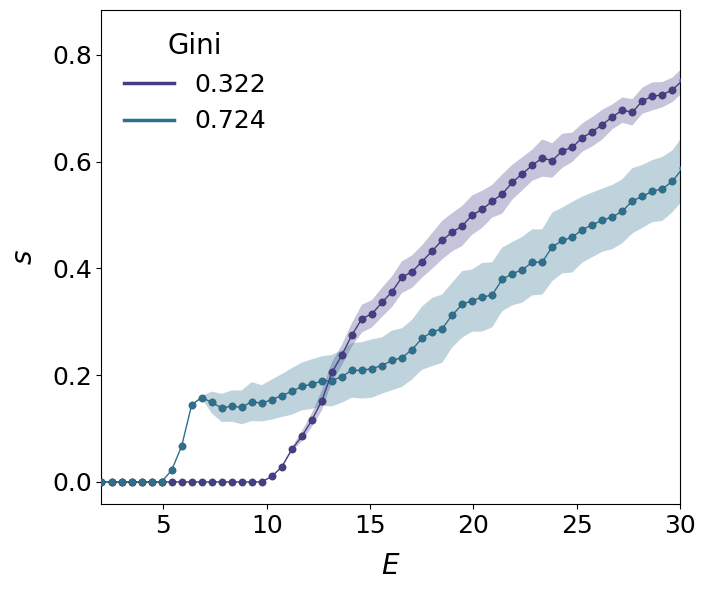

In [76]:
# ============================================================
# Plot: sincronización frente a excitación
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pypalettes import load_cmap
base_sigma1 = 0.50
output_file = f"Sync_VS_ExcitatioN_{base_sigma1:.2f}_MEAN.csv"
base_sigma2 = 0.05
output_file2 = f"Sync_VS_ExcitatioN_{base_sigma2:.2f}_MEAN.csv"
df_results1 = pd.read_csv(output_file)
df_results2 = pd.read_csv(output_file2)
gini_value1 = (
    float(df_results1["Gini"].dropna().iloc[0])
    if "Gini" in df_results1.columns and not df_results1["Gini"].dropna().empty
    else np.nan
)
gini_value2 = (
    float(df_results2["Gini"].dropna().iloc[0])
    if "Gini" in df_results2.columns and not df_results2["Gini"].dropna().empty
    else np.nan
)
gini_text1 = f"{gini_value1:.3f}" if np.isfinite(gini_value1) else "NaN"
gini_text2 = f"{gini_value2:.3f}" if np.isfinite(gini_value2) else "NaN"

viridis = load_cmap("viridis")

plt.figure(figsize=(7, 6))

plt.plot(
    df_results1["MAX_EXC_WEIGHT"],
    df_results1["mean_peak_height_weighted"],
    color=viridis(0.1),
    label=gini_text1, 
    lw = 1
)

plt.scatter(
    df_results1["MAX_EXC_WEIGHT"],
    df_results1["mean_peak_height_weighted"],
    color=viridis(0.1),
    edgecolor="black",
    linewidth=0.1,
    s=30,
    zorder=3
)

plt.fill_between(
    df_results1["MAX_EXC_WEIGHT"],
    df_results1["mean_peak_height_weighted"] - df_results1["error_mean_peak_height_weighted"],
    df_results1["mean_peak_height_weighted"] + df_results1["error_mean_peak_height_weighted"],
    color=viridis(0.1),
    alpha=0.3, 
    edgecolor="none"
)

plt.plot(
    df_results2["MAX_EXC_WEIGHT"],
    df_results2["mean_peak_height_weighted"],
    color=viridis(0.3),
    label=gini_text2,
    lw = 1
)
plt.scatter(
    df_results2["MAX_EXC_WEIGHT"],
    df_results2["mean_peak_height_weighted"],
    color=viridis(0.3),
    edgecolor="black",
    linewidth=0.1,
    s=30,
    zorder=3
)
plt.fill_between(
    df_results2["MAX_EXC_WEIGHT"],
    df_results2["mean_peak_height_weighted"] - df_results2["error_mean_peak_height_weighted"],
    df_results2["mean_peak_height_weighted"] + df_results2["error_mean_peak_height_weighted"],
    color=viridis(0.3),
    alpha=0.3, 
    edgecolor="none"
)


plt.xlabel(r"$E$", fontsize = 20, labelpad = 10)
plt.ylabel(r"$s$", fontsize = 20, labelpad = 10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.title(f"Synchronisation vs excitation | Gini = {Gini:.3f}")
leg = plt.legend(title="Gini", fontsize=18, title_fontsize=20, frameon=False)
for legline in leg.get_lines():
    legline.set_linewidth(2.5)



# plt.text(
#     0.75, 0.1,
#     rf"$\Lambda = {gini_text}$",
#     ha="center", va="center",
#     transform=plt.gca().transAxes,
#     fontsize=20
# )
# plt.grid(alpha=0.3)
plt.tight_layout()
plt.xlim(2, 30)
plt.show()



In [3]:
import os
import numpy as np
import pandas as pd
import networkx as nx

# ============================================================
# Parámetros principales
# ============================================================

L = 1.5
N = 1000

Neuron_per_center = 80
frac_agg = 0.8
n_centers = N // Neuron_per_center

# Barrido en agregación
base_sigmas = np.linspace(0.05, 0.5, 50)

r_conn = 0.15
alpha = 0.5

seed = 113
n_reps = 5

directed = True

output_file = "Network_metrics_vs_base_sigma.csv"


# ============================================================
# Función para calcular Gini espacial en 2D usando todas las neuronas
# ============================================================

def compute_spatial_gini_2D(positions, L, bins=18):
    """
    Calcula el índice de Gini espacial usando una discretización
    del espacio en una malla 2D.

    Gini bajo  -> distribución más homogénea
    Gini alto  -> distribución más agregada
    """

    H, _, _ = np.histogram2d(
        positions[:, 0],
        positions[:, 1],
        bins=bins,
        range=[[-L/2, L/2], [-L/2, L/2]]
    )

    x = H.ravel().astype(float)

    if np.sum(x) == 0:
        return np.nan

    x_sorted = np.sort(x)
    n = len(x_sorted)

    gini = (
        2 * np.sum(np.arange(1, n + 1) * x_sorted)
        / (n * np.sum(x_sorted))
        - (n + 1) / n
    )

    return gini


# ============================================================
# Función para obtener componente gigante
# ============================================================

def get_giant_component_nodes(A, directed=True):
    """
    Devuelve los nodos de la componente gigante.

    Si la red es dirigida, usa componente débilmente conexa.
    """

    if directed:
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)

        if nx.is_weakly_connected(G):
            GC_nodes = np.arange(A.shape[0])
        else:
            GC = max(nx.weakly_connected_components(G), key=len)
            GC_nodes = np.array(sorted(list(GC)))

    else:
        G = nx.from_numpy_array(A)

        if nx.is_connected(G):
            GC_nodes = np.arange(A.shape[0])
        else:
            GC = max(nx.connected_components(G), key=len)
            GC_nodes = np.array(sorted(list(GC)))

    return GC_nodes


# ============================================================
# Función para calcular métricas estructurales
# ============================================================

def compute_network_metrics(A_gc, seed_louvain=0):
    """
    Calcula métricas estructurales sobre la componente gigante.

    - mean_degree_in: sobre la red dirigida.
    - clustering: sobre la red no dirigida.
    - modularity_Q: Louvain sobre la red no dirigida.
    - avg_shortest_path: sobre la red no dirigida.
    """

    # Red dirigida
    G_dir = nx.from_numpy_array(A_gc, create_using=nx.DiGraph)

    # Red no dirigida equivalente
    G_und = G_dir.to_undirected()

    # Eliminar posibles self-loops
    G_dir.remove_edges_from(nx.selfloop_edges(G_dir))
    G_und.remove_edges_from(nx.selfloop_edges(G_und))

    # --------------------------------------------------------
    # Grado medio in
    # --------------------------------------------------------

    mean_degree_in = np.mean([d for _, d in G_dir.in_degree()])

    # --------------------------------------------------------
    # Clustering medio
    # --------------------------------------------------------

    clustering = nx.average_clustering(G_und)

    # --------------------------------------------------------
    # Modularidad Louvain
    # --------------------------------------------------------

    try:
        communities = nx.community.louvain_communities(
            G_und,
            seed=seed_louvain,
            weight=None
        )

        modularity_Q = nx.community.modularity(
            G_und,
            communities,
            weight=None
        )

    except Exception as e:
        print("Aviso: no se pudo calcular Louvain/modularidad.")
        print(e)
        modularity_Q = np.nan

    # --------------------------------------------------------
    # Average shortest path
    # --------------------------------------------------------

    if G_und.number_of_nodes() <= 1:
        avg_shortest_path = np.nan
    else:
        avg_shortest_path = nx.average_shortest_path_length(G_und)

    return mean_degree_in, clustering, modularity_Q, avg_shortest_path


# ============================================================
# Bucle principal: barrido en base_sigma
# ============================================================

results = []

for i_sigma, base_sigma in enumerate(base_sigmas):

    for rep in range(n_reps):

        print(
            f"base_sigma {i_sigma + 1}/{len(base_sigmas)} | "
            f"sigma = {base_sigma:.4f} | "
            f"rep = {rep + 1}/{n_reps}"
        )

        # Semilla distinta para cada red
        current_seed = seed + 1000 * rep + i_sigma
        rng = np.random.default_rng(current_seed)

        # ====================================================
        # Generar posiciones
        # ====================================================

        positions, centers, labels, sigmas = generate_mixed_positions(
            N=N,
            L=L,
            frac_agg=frac_agg,
            n_centers=n_centers,
            base_sigma=base_sigma,
            rng=rng,
            sigma_mode="same",
            sigma_min=0.05,
            sigma_max=0.20
        )

        # ====================================================
        # Calcular Gini usando TODAS las neuronas
        # ====================================================

        Gini = compute_spatial_gini_2D(
            positions=positions,
            L=L,
            bins=18
        )

        # ====================================================
        # Crear red
        # ====================================================

        A_full = create_distance_network(
            positions=positions,
            r_conn=r_conn,
            alpha=alpha,
            directed=directed,
            rng=rng
        )

        np.fill_diagonal(A_full, 0)

        # ====================================================
        # Componente gigante
        # ====================================================

        GC_nodes = get_giant_component_nodes(
            A=A_full,
            directed=directed
        )

        A_gc = A_full[np.ix_(GC_nodes, GC_nodes)]

        # ====================================================
        # Calcular métricas estructurales
        # ====================================================

        mean_degree_in, clustering, modularity_Q, avg_shortest_path = compute_network_metrics(
            A_gc=A_gc,
            seed_louvain=current_seed
        )

        print(
            f"    Gini = {Gini:.4f} | "
            f"<k_in> = {mean_degree_in:.3f} | "
            f"C = {clustering:.3f} | "
            f"Q = {modularity_Q:.3f} | "
            f"ASP = {avg_shortest_path:.3f}"
        )

        # ====================================================
        # Guardar solo las columnas que quieres
        # ====================================================

        results.append({
            "base_sigma": base_sigma,
            "Gini": Gini,
            "mean_degree_in": mean_degree_in,
            "clustering": clustering,
            "modularity_Q": modularity_Q,
            "avg_shortest_path": avg_shortest_path
        })

        # Guardado incremental
        pd.DataFrame(results).to_csv(output_file, index=False)


# ============================================================
# Guardado final
# ============================================================

df_results = pd.DataFrame(results)

df_results = df_results.sort_values(
    ["base_sigma", "Gini"]
).reset_index(drop=True)

df_results.to_csv(output_file, index=False)

print(f"\nResultados guardados en: {output_file}")
print(df_results.head())

base_sigma 1/50 | sigma = 0.0500 | rep = 1/5
    Gini = 0.7240 | <k_in> = 30.174 | C = 0.610 | Q = 0.859 | ASP = 7.959
base_sigma 1/50 | sigma = 0.0500 | rep = 2/5
    Gini = 0.7420 | <k_in> = 35.395 | C = 0.590 | Q = 0.787 | ASP = 6.391
base_sigma 1/50 | sigma = 0.0500 | rep = 3/5
    Gini = 0.7294 | <k_in> = 35.353 | C = 0.596 | Q = 0.815 | ASP = 8.917
base_sigma 1/50 | sigma = 0.0500 | rep = 4/5
    Gini = 0.7362 | <k_in> = 38.153 | C = 0.599 | Q = 0.784 | ASP = 7.319
base_sigma 1/50 | sigma = 0.0500 | rep = 5/5
    Gini = 0.7472 | <k_in> = 39.604 | C = 0.601 | Q = 0.798 | ASP = 6.324
base_sigma 2/50 | sigma = 0.0592 | rep = 1/5
    Gini = 0.7007 | <k_in> = 33.711 | C = 0.576 | Q = 0.776 | ASP = 6.997
base_sigma 2/50 | sigma = 0.0592 | rep = 2/5
    Gini = 0.7046 | <k_in> = 36.859 | C = 0.573 | Q = 0.784 | ASP = 6.371
base_sigma 2/50 | sigma = 0.0592 | rep = 3/5
    Gini = 0.7000 | <k_in> = 33.334 | C = 0.576 | Q = 0.834 | ASP = 7.467
base_sigma 2/50 | sigma = 0.0592 | rep = 4/5
   

In [8]:
import pandas as pd

# ============================================================
# Fichero de entrada y salida
# ============================================================

input_file = "Network_metrics_vs_base_sigma.csv"
output_file = "Network_metrics_vs_base_sigma_MEAN.csv"

# ============================================================
# Leer datos
# ============================================================

df = pd.read_csv(input_file)

# ============================================================
# Columnas que quieres promediar
# ============================================================

cols_to_average = [
    "Gini",
    "mean_degree_in",
    "clustering",
    "modularity_Q",
    "avg_shortest_path"
]

# ============================================================
# Agrupar por base_sigma y calcular media + std
# ============================================================

df_mean = (
    df
    .groupby("base_sigma", as_index=False)
    .agg(
        Gini_mean=("Gini", "mean"),
        Gini_std=("Gini", "std"),

        mean_degree_in_mean=("mean_degree_in", "mean"),
        mean_degree_in_std=("mean_degree_in", "std"),

        clustering_mean=("clustering", "mean"),
        clustering_std=("clustering", "std"),

        modularity_Q_mean=("modularity_Q", "mean"),
        modularity_Q_std=("modularity_Q", "std"),

        avg_shortest_path_mean=("avg_shortest_path", "mean"),
        avg_shortest_path_std=("avg_shortest_path", "std"),
    )
)

# Si alguna base_sigma solo tiene una simulación, la std sale NaN.
# Si quieres que en ese caso sea 0, deja esta línea.
df_mean = df_mean.fillna(0)

# ============================================================
# Ordenar y guardar
# ============================================================

df_mean = df_mean.sort_values("base_sigma").reset_index(drop=True)

df_mean.to_csv(output_file, index=False)

print(f"Fichero promediado guardado en: {output_file}")
print(df_mean.head())

Fichero promediado guardado en: Network_metrics_vs_base_sigma_MEAN.csv
   base_sigma  Gini_mean  Gini_std  mean_degree_in_mean  mean_degree_in_std  \
0    0.050000   0.735763  0.009365            35.735904            3.605376   
1    0.059184   0.705910  0.006376            34.827516            2.734005   
2    0.068367   0.665170  0.013124            31.129209            1.269518   
3    0.077551   0.654402  0.015579            32.600444            3.153484   
4    0.086735   0.631157  0.023078            30.249342            3.691682   

   clustering_mean  clustering_std  modularity_Q_mean  modularity_Q_std  \
0         0.599188        0.007668           0.808418          0.030530   
1         0.576618        0.010549           0.791092          0.034185   
2         0.571568        0.005444           0.816007          0.019751   
3         0.542741        0.016975           0.767395          0.055844   
4         0.519785        0.007418           0.730987          0.061013   

   

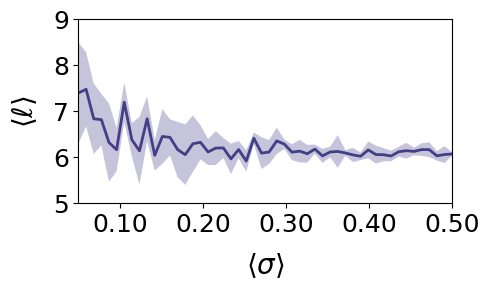

In [34]:
from pypalettes import load_cmap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

out_filename = "Network_metrics_vs_base_sigma_MEAN.csv"
df_results = pd.read_csv(out_filename)

# base_sigmas = df_results["base_sigma"].unique()
viridis = load_cmap("viridis")
plt.figure(figsize=(5, 3))
plt.plot(
    df_results["base_sigma"],
    df_results["avg_shortest_path_mean"],
    color=viridis(0.1),
    label="In-degree",
    lw=2
)
plt.fill_between(
    df_results["base_sigma"],
    df_results["avg_shortest_path_mean"] - df_results["avg_shortest_path_std"],
    df_results["avg_shortest_path_mean"] + df_results["avg_shortest_path_std"],
    color=viridis(0.1),
    alpha=0.3,
    edgecolor="none"
)
plt.xlabel(r"$\langle\sigma\rangle$", fontsize=20, labelpad=10)
plt.ylabel(r"$\langle \ell \rangle$", fontsize=20, labelpad=10)
xticks = plt.xticks()[0]
plt.xticks(xticks, [f"{x:.2f}" for x in xticks], fontsize=18)
yticks = plt.yticks()[0]
yticks = [5,6,7,8,9]
plt.yticks(yticks, [f"{x:.0f}" for x in yticks], fontsize=18)
plt.yticks(fontsize=18)
plt.tight_layout()
plt.xlim(0.05, 0.5)
# plt.savefig(out_filename, dpi=300, bbox_inches='tight')
plt.show()


In [35]:
import numpy as np
import pandas as pd
import networkx as nx

# ============================================================
# Parámetros principales
# ============================================================

L = 1.5
N = 1000

Neuron_per_center = 80
frac_agg = 0.8
n_centers = N // Neuron_per_center

base_sigma = 0.50

r_conn = 0.15
alpha = 0.5

seed = 113
n_reps = 20

directed = True
use_giant_component = True

output_file = f"Degree_distribution_k_in_base_sigma_{base_sigma:.3f}.csv"


# ============================================================
# Componente gigante débilmente conexa
# ============================================================

def get_giant_component_nodes(A, directed=True):

    if directed:
        G = nx.from_numpy_array(A, create_using=nx.DiGraph)

        if nx.is_weakly_connected(G):
            GC_nodes = np.arange(A.shape[0])
        else:
            GC = max(nx.weakly_connected_components(G), key=len)
            GC_nodes = np.array(sorted(list(GC)))

    else:
        G = nx.from_numpy_array(A)

        if nx.is_connected(G):
            GC_nodes = np.arange(A.shape[0])
        else:
            GC = max(nx.connected_components(G), key=len)
            GC_nodes = np.array(sorted(list(GC)))

    return GC_nodes


# ============================================================
# Simulaciones
# ============================================================

all_distributions = []
sim_ids = []

for rep in range(n_reps):

    print(f"Simulación {rep + 1}/{n_reps}")

    current_seed = seed + 1000 * rep
    rng = np.random.default_rng(current_seed)

    # --------------------------------------------------------
    # Generar posiciones
    # --------------------------------------------------------

    positions, centers, labels, sigmas = generate_mixed_positions(
        N=N,
        L=L,
        frac_agg=frac_agg,
        n_centers=n_centers,
        base_sigma=base_sigma,
        rng=rng,
        sigma_mode="same",
        sigma_min=0.05,
        sigma_max=0.20
    )

    # --------------------------------------------------------
    # Crear red
    # --------------------------------------------------------

    A_full = create_distance_network(
        positions=positions,
        r_conn=r_conn,
        alpha=alpha,
        directed=directed,
        rng=rng
    )

    np.fill_diagonal(A_full, 0)

    # --------------------------------------------------------
    # Componente gigante o red completa
    # --------------------------------------------------------

    if use_giant_component:

        GC_nodes = get_giant_component_nodes(
            A=A_full,
            directed=directed
        )

        A_use = A_full[np.ix_(GC_nodes, GC_nodes)]

    else:

        A_use = A_full

    # --------------------------------------------------------
    # Grado de entrada k_in
    # --------------------------------------------------------

    G_dir = nx.from_numpy_array(A_use, create_using=nx.DiGraph)
    G_dir.remove_edges_from(nx.selfloop_edges(G_dir))

    k_in = np.array([d for _, d in G_dir.in_degree()], dtype=int)

    # --------------------------------------------------------
    # Distribución P(k)
    # --------------------------------------------------------

    counts = np.bincount(k_in)
    P_k = counts / counts.sum()

    for k, pk in enumerate(P_k):
        all_distributions.append({
            "rep": rep,
            "k": k,
            "P_k": pk
        })

    sim_ids.append(rep)

    print(
        f"    N_used = {A_use.shape[0]} | "
        f"<k_in> = {k_in.mean():.3f} | "
        f"k_max = {k_in.max()}"
    )


# ============================================================
# DataFrame con distribuciones individuales
# ============================================================

df_raw = pd.DataFrame(all_distributions)

# ============================================================
# Completar grados ausentes con P(k)=0
# ============================================================

max_k_global = int(df_raw["k"].max())

grid = pd.MultiIndex.from_product(
    [sim_ids, np.arange(max_k_global + 1)],
    names=["rep", "k"]
).to_frame(index=False)

df_complete = grid.merge(
    df_raw,
    on=["rep", "k"],
    how="left"
)

df_complete["P_k"] = df_complete["P_k"].fillna(0.0)


# ============================================================
# Promediar P(k) entre simulaciones
# ============================================================

df_final = (
    df_complete
    .groupby("k", as_index=False)
    .agg(
        P_k=("P_k", "mean"),
        P_k_error=("P_k", lambda x: x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0)
    )
)

# ============================================================
# Guardar SOLO k, P(k) y error
# ============================================================

df_final = df_final[["k", "P_k", "P_k_error"]]

df_final.to_csv(output_file, index=False)

print(f"\nFichero guardado en: {output_file}")
print(df_final.head())

Simulación 1/20
    N_used = 1000 | <k_in> = 15.122 | k_max = 32
Simulación 2/20
    N_used = 1000 | <k_in> = 15.788 | k_max = 35
Simulación 3/20
    N_used = 1000 | <k_in> = 15.451 | k_max = 30
Simulación 4/20
    N_used = 1000 | <k_in> = 15.858 | k_max = 34
Simulación 5/20
    N_used = 1000 | <k_in> = 15.224 | k_max = 31
Simulación 6/20
    N_used = 1000 | <k_in> = 15.806 | k_max = 33
Simulación 7/20
    N_used = 1000 | <k_in> = 17.108 | k_max = 36
Simulación 8/20
    N_used = 1000 | <k_in> = 15.368 | k_max = 30
Simulación 9/20
    N_used = 1000 | <k_in> = 15.878 | k_max = 35
Simulación 10/20
    N_used = 1000 | <k_in> = 14.885 | k_max = 31
Simulación 11/20
    N_used = 999 | <k_in> = 15.819 | k_max = 31
Simulación 12/20
    N_used = 1000 | <k_in> = 15.352 | k_max = 36
Simulación 13/20
    N_used = 1000 | <k_in> = 15.115 | k_max = 35
Simulación 14/20
    N_used = 1000 | <k_in> = 15.539 | k_max = 36
Simulación 15/20
    N_used = 1000 | <k_in> = 15.278 | k_max = 31
Simulación 16/20
   

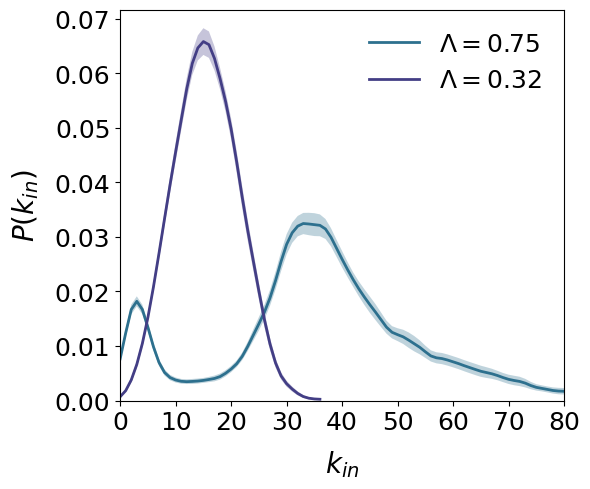

In [47]:
from scipy.ndimage import gaussian_filter1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

filename050 = "Degree_distribution_k_in_base_sigma_0.050.csv"
filename500 = "Degree_distribution_k_in_base_sigma_0.500.csv"

df050 = pd.read_csv(filename050)
df500 = pd.read_csv(filename500)

# ============================================================
# Función de suavizado
# ============================================================

def smooth_degree_distribution(df, sigma_smooth=1.2):
    """
    Suaviza P(k) y su error con un filtro gaussiano.
    Después renormaliza P(k) para que la suma sea 1.
    """

    df = df.copy()
    df = df.sort_values("k").reset_index(drop=True)

    P = df["P_k"].values
    err = df["P_k_error"].values

    P_smooth = gaussian_filter1d(P, sigma=sigma_smooth, mode="nearest")
    err_smooth = gaussian_filter1d(err, sigma=sigma_smooth, mode="nearest")

    # Evitar valores negativos numéricos
    P_smooth = np.clip(P_smooth, 0, None)
    err_smooth = np.clip(err_smooth, 0, None)

    # Renormalizar distribución
    if P_smooth.sum() > 0:
        P_smooth = P_smooth / P_smooth.sum()

    df["P_k_smooth"] = P_smooth
    df["P_k_error_smooth"] = err_smooth

    return df


# ============================================================
# Aplicar suavizado
# ============================================================

sigma_smooth = 1.2   # prueba 0.8, 1.2, 1.8, 2.5

df050_s = smooth_degree_distribution(df050, sigma_smooth=sigma_smooth)
df500_s = smooth_degree_distribution(df500, sigma_smooth=sigma_smooth)


# ============================================================
# Plot
# ============================================================

plt.figure(figsize=(6, 5))

plt.plot(
    df050_s["k"],
    df050_s["P_k_smooth"],
    color=viridis(0.3),
    label=r"$\Lambda = 0.75$",
    lw=2
)

plt.fill_between(
    df050_s["k"],
    np.clip(df050_s["P_k_smooth"] - df050_s["P_k_error_smooth"], 0, None),
    df050_s["P_k_smooth"] + df050_s["P_k_error_smooth"],
    color=viridis(0.3),
    alpha=0.3,
    edgecolor="none"
)

plt.plot(
    df500_s["k"],
    df500_s["P_k_smooth"],
    color=viridis(0.1),
    label=r"$\Lambda = 0.32$",
    lw=2
)

plt.fill_between(
    df500_s["k"],
    np.clip(df500_s["P_k_smooth"] - df500_s["P_k_error_smooth"], 0, None),
    df500_s["P_k_smooth"] + df500_s["P_k_error_smooth"],
    color=viridis(0.1),
    alpha=0.3,
    edgecolor="none"
)

plt.xlabel(r"$k_{in}$", fontsize=20, labelpad=10)
plt.ylabel(r"$P(k_{in})$", fontsize=20, labelpad=10)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18, frameon=False)

# Ajusta si quieres centrarte en una zona concreta
plt.xlim(0, 80)

plt.ylim(0, None)
plt.tight_layout()
plt.show()